In [7]:
import cv2
import time
import os
import numpy as np
import matplotlib.pyplot as plt

import lane_detection
import vehicle_detection
import sign_detection

print("Libraries and modules imported successfully.")

Libraries and modules imported successfully.


In [8]:
video = './sample videos/adas_sample_video.mp4'
annotated = './output/annotated_video.mp4'
sample_frames = './output/sample_frames/'

# Create the output directory if it doesn't exist
os.makedirs(os.path.dirname(annotated), exist_ok=True)
os.makedirs(sample_frames, exist_ok=True)

## Part 1: System Performance Analysis (FPS & Latency)

This section analyzes the computational performance of the ADAS pipeline. It processes the input video to measure processing speed and identify which parts of the code are the slowest.

In [9]:
def analyze_system_performance(video_path):
    print("--- Starting System Performance Analysis ---")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file at {video_path}")
        return None

    vd = vehicle_detection.VehicleDetector()
    sd = sign_detection.SignDetector()

    timings = {
        'Lane Detection': [], 'Vehicle Detection': [],
        'Sign Detection': [], 'Total Frame': []
    }
    frame_count = 0
    max_frames = 300 # Limit to 300 frames for a reasonably quick test

    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret: break
        
        frame_start_time = time.time()
        
        start = time.time()
        frame_with_lanes = lane_detection.process_frame(frame)
        timings['Lane Detection'].append(time.time() - start)
        
        start = time.time()
        frame_with_vehicles = vd.detect_vehicles(frame_with_lanes)
        timings['Vehicle Detection'].append(time.time() - start)
        
        start = time.time()
        _ = sd.detect_signs(frame_with_vehicles)
        timings['Sign Detection'].append(time.time() - start)
        
        timings['Total Frame'].append(time.time() - frame_start_time)
        frame_count += 1
        print(f"\rAnalyzing performance on frame {frame_count}/{max_frames}...", end="")

    cap.release()
    print("\n\n--- System Performance Results ---")
    
    if not frame_count:
        print("No frames were processed.")
        return None

    total_time = sum(timings['Total Frame'])
    avg_fps = frame_count / total_time
    
    print(f"Average FPS: {avg_fps:.2f}")
    print("\nAverage Latency Breakdown:")
    
    avg_timings_ms = {}
    for component, times in timings.items():
        if times:
            avg_time_ms = (sum(times) / len(times)) * 1000
            print(f"- {component}: {avg_time_ms:.2f} ms")
            avg_timings_ms[component] = avg_time_ms
    
    return avg_timings_ms

# Run the performance analysis
performance_data = analyze_system_performance(video)

--- Starting System Performance Analysis ---
YOLOv8 vehicle model loaded successfully.
Custom-trained traffic sign model loaded successfully.
Model can detect the following signs: ['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']

0: 384x640 1 car, 70.6ms
Speed: 3.9ms preprocess, 70.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 52.5ms
Speed: 1.2ms preprocess, 52.5ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
Analyzing performance on frame 1/300...
0: 384x640 1 car, 58.4ms
Speed: 1.3ms preprocess, 58.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Speed Limit 50, 1 Speed Limit 80, 51.0ms
Speed: 1.1ms preprocess, 51.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384,

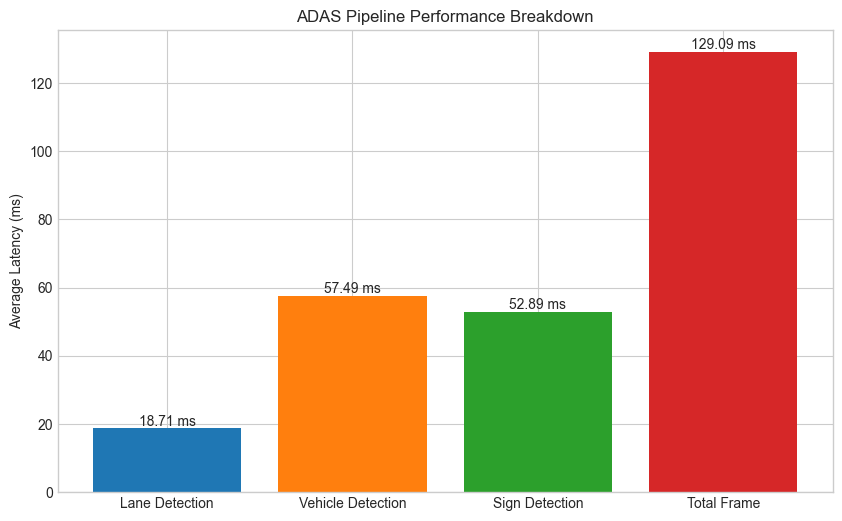

In [10]:
# --- Visualize Performance Results ---
if performance_data:
    components = list(performance_data.keys())
    latencies = list(performance_data.values())

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bars = ax.bar(components, latencies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    ax.set_ylabel('Average Latency (ms)')
    ax.set_title('ADAS Pipeline Performance Breakdown')
    ax.bar_label(bars, fmt='%.2f ms')
    
    plt.show()

## Part 2: Qualitative Review & Dataset Curation

This section runs the full ADAS pipeline on the entire input video and does two things:
1.  **Saves a new annotated video**: This video will have all the lane, vehicle, and sign detections drawn on it. You can watch this output to visually assess the model's performance in different scenarios.
2.  **Saves sample frames**: It automatically saves individual frames that contain a high number of detected objects. These images are perfect candidates to be labeled later to create your own ground truth dataset.

In [11]:
def generate_annotated_video_and_dataset(input_video_path, output_video_path, sample_frames_folder):
    """
    Processes a video to create an annotated version and save sample frames for dataset creation.
    """
    print("\n--- Starting Video Annotation and Frame Curation ---")
    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file at {input_video_path}")
        return

    # Get video properties for the output writer
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Setup video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    vd = vehicle_detection.VehicleDetector()
    sd = sign_detection.SignDetector()
    
    frame_num = 0
    last_saved_time = -5 # Used to avoid saving too many frames close together

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # Run the full ADAS pipeline
        frame_with_lanes = lane_detection.process_frame(frame)
        
        # Modify the detector to return the boxes for analysis
        # We need to temporarily adapt the call to get the detection count
        vehicle_results = vd.model(frame_with_lanes, verbose=False)
        annotated_frame = vehicle_results[0].plot() # Use ultralytics plot function
        
        sign_results = sd.model(annotated_frame, conf=0.3, verbose=False)
        final_frame = sign_results[0].plot()

        # Write the frame to the output video
        out.write(final_frame)
        
        # Logic to save interesting frames
        num_vehicles = len(vehicle_results[0].boxes)
        current_time = frame_num / fps
        
        # Save frame if more than 2 vehicles are detected and it's been 3 seconds since the last save
        if num_vehicles > 2 and (current_time - last_saved_time > 3):
            filename = f"frame_{frame_num:05d}_vehicles_{num_vehicles}.jpg"
            save_path = os.path.join(sample_frames_folder, filename)
            cv2.imwrite(save_path, frame) # Save the original frame for labeling
            print(f"\nSaved interesting frame: {filename}")
            last_saved_time = current_time

        frame_num += 1
        print(f"\rProcessing video frame {frame_num}/{total_frames}...", end="")

    cap.release()
    out.release()
    print(f"\n\nAnnotation complete! Annotated video saved to: {output_video_path}")
    print(f"Sample frames for dataset saved to: {sample_frames_folder}")

# Run the generation process
generate_annotated_video_and_dataset(video, annotated, sample_frames)


--- Starting Video Annotation and Frame Curation ---
YOLOv8 vehicle model loaded successfully.
Custom-trained traffic sign model loaded successfully.
Model can detect the following signs: ['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']
Processing video frame 3/192...
Saved interesting frame: frame_00003_vehicles_3.jpg
Processing video frame 76/192...
Saved interesting frame: frame_00076_vehicles_4.jpg
Processing video frame 148/192...
Saved interesting frame: frame_00148_vehicles_6.jpg
Processing video frame 192/192...

Annotation complete! Annotated video saved to: ./output/annotated_video.mp4
Sample frames for dataset saved to: ./output/sample_frames/
